# Evaluation

In [3]:
import pandas as pd

df = pd.read_csv('results/summary.csv')
metrics = ['accuracy','f1_weighted','roc_auc_ovr','log_loss']
for cv in ['kfold','loso']:
    print(cv.upper())
    for region in ['mouth','nose']:
        sub = df[(df.cv_mode==cv)&(df.region==region)]
        print(f'  {region:6s} (n={len(sub)} folds)')
        for m in metrics:
            print(f'    {m:14s}: {sub[m].mean():.4f} ± {sub[m].std():.4f}')


KFOLD
  mouth  (n=25 folds)
    accuracy      : 0.8534 ± 0.0432
    f1_weighted   : 0.8520 ± 0.0455
    roc_auc_ovr   : 0.9603 ± 0.0241
    log_loss      : 0.3764 ± 0.0737
  nose   (n=25 folds)
    accuracy      : 0.7269 ± 0.0296
    f1_weighted   : 0.7259 ± 0.0297
    roc_auc_ovr   : 0.8924 ± 0.0224
    log_loss      : 0.6424 ± 0.0597
LOSO
  mouth  (n=25 folds)
    accuracy      : 0.7816 ± 0.0953
    f1_weighted   : 0.7747 ± 0.1005
    roc_auc_ovr   : 0.9275 ± 0.0424
    log_loss      : 0.5298 ± 0.1641
  nose   (n=25 folds)
    accuracy      : 0.5392 ± 0.0591
    f1_weighted   : 0.5018 ± 0.0580
    roc_auc_ovr   : 0.7662 ± 0.1074
    log_loss      : 0.9585 ± 0.2359


In [1]:
import numpy as np
import torch

device = torch.device("cpu")

### Exploratory Data Analysis

In [2]:
from core.plotting import load_breath_pattern, load_cir, plot_measurements, plot_region_comparison, plot_interparticipant_variability, plot_correlation, plot_cir

In [3]:
# load data
CLASSES  = ["bradypnea", "eupnea", "tachypnea"]
t=np.linspace(0, 70, 300)
breath_pattern = load_breath_pattern(classes=CLASSES, dataset_dir="./dataset")
print(f"Total trials:\t\t\t{len(breath_pattern)},\nClasses:\t\t\t{breath_pattern["class"].unique()},\nParticipants:\t\t\t{breath_pattern["participant"].unique()}")

records = breath_pattern.to_dict("records")
durations = np.array([row["time"][-1] - row["time"][0] for row in records])
n_samples = np.array([len(row["time"]) for row in records])
all_intervals = np.concatenate([np.diff(row["time"]) for row in records])
print(f"Samples per trial:\t\tmin={n_samples.min()}, max={n_samples.max()}, mean={n_samples.mean():.1f}")
print(f"Trial duration (s):\t\tmin={durations.min():.1f}, max={durations.max():.1f}, mean={durations.mean():.1f}")
print(f"Sampling interval (ms):\t\tmean={all_intervals.mean()*1000:.0f}, std={all_intervals.std()*1000:.0f}")
print(f"Effective sampling rate:\t~{1/all_intervals.mean():.3f} Hz")
print(f"Nyquist limit:\t\t\t{0.5/all_intervals.mean():.2f} Hz -> max detectable breath rate: {0.5/all_intervals.mean()*60:.0f} BPM")

Total trials:			1066,
Classes:			['bradypnea' 'eupnea' 'tachypnea'],
Participants:			['e' 'f' 'g' 'a' 'p' 's']
Samples per trial:		min=36, max=36, mean=36.0
Trial duration (s):		min=70.0, max=70.2, mean=70.1
Sampling interval (ms):		mean=2003, std=2
Effective sampling rate:	~0.499 Hz
Nyquist limit:			0.25 Hz -> max detectable breath rate: 15 BPM


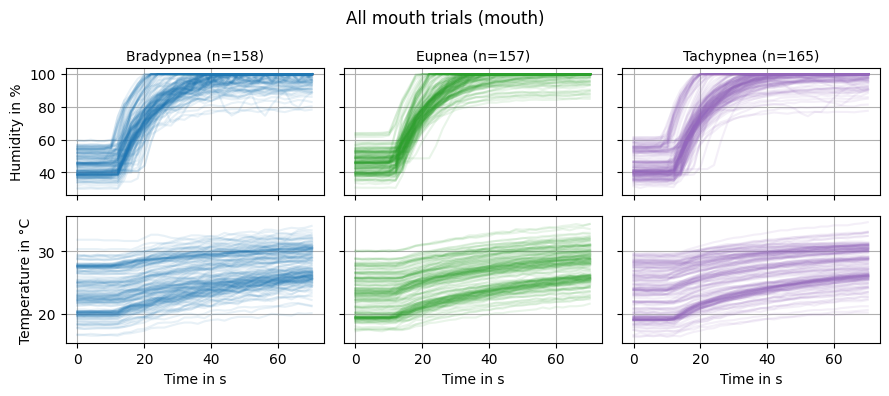

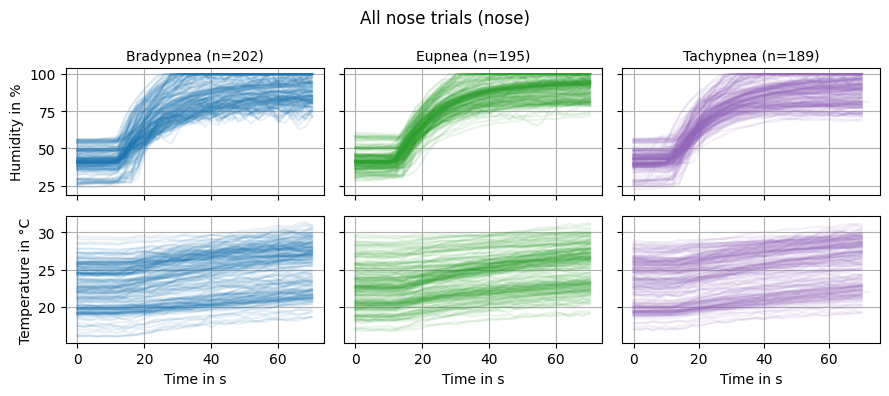

In [4]:
plot_measurements(breath_pattern, region="mouth")
plot_measurements(breath_pattern, region="nose")

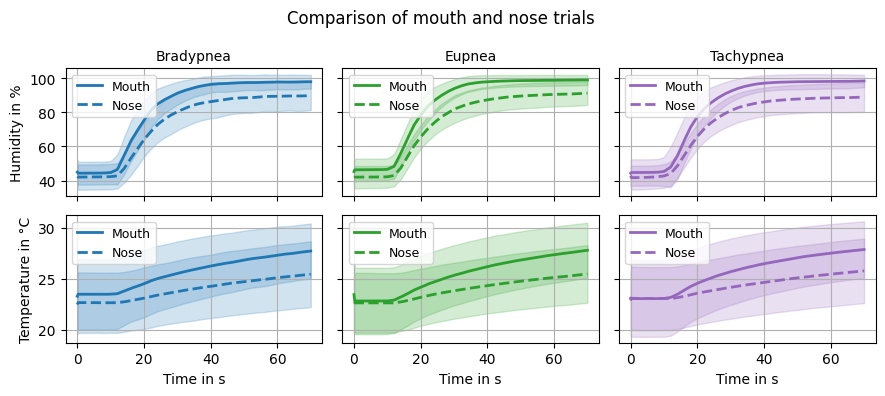

In [5]:
plot_region_comparison(breath_pattern, t)

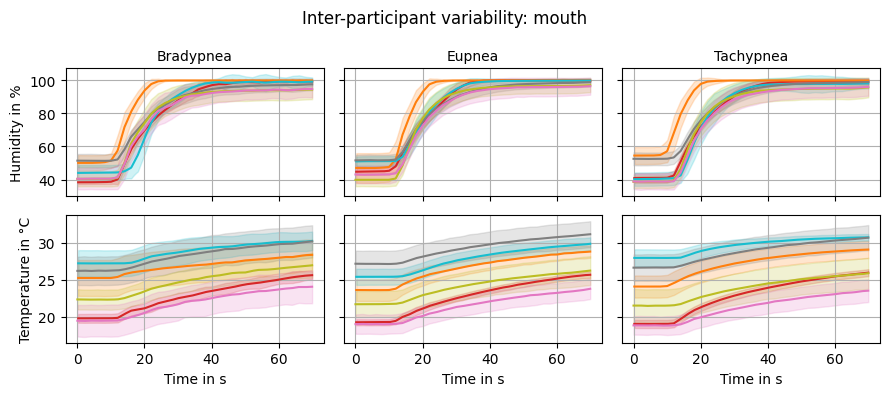

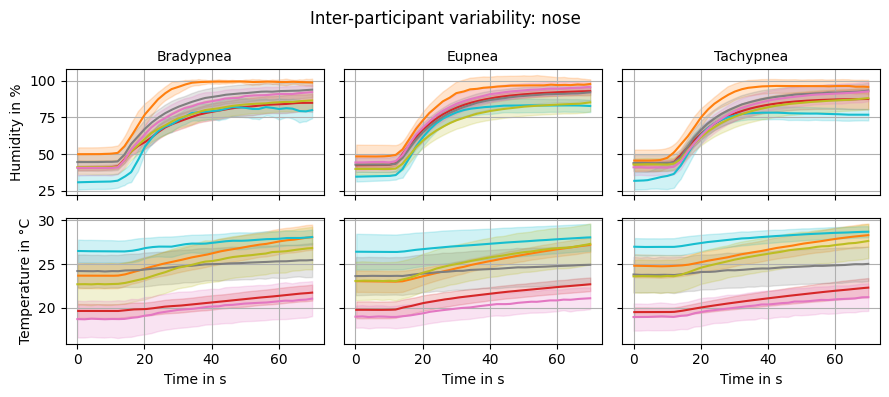

In [6]:
plot_interparticipant_variability(breath_pattern, t, region="mouth")
plot_interparticipant_variability(breath_pattern, t, region="nose")

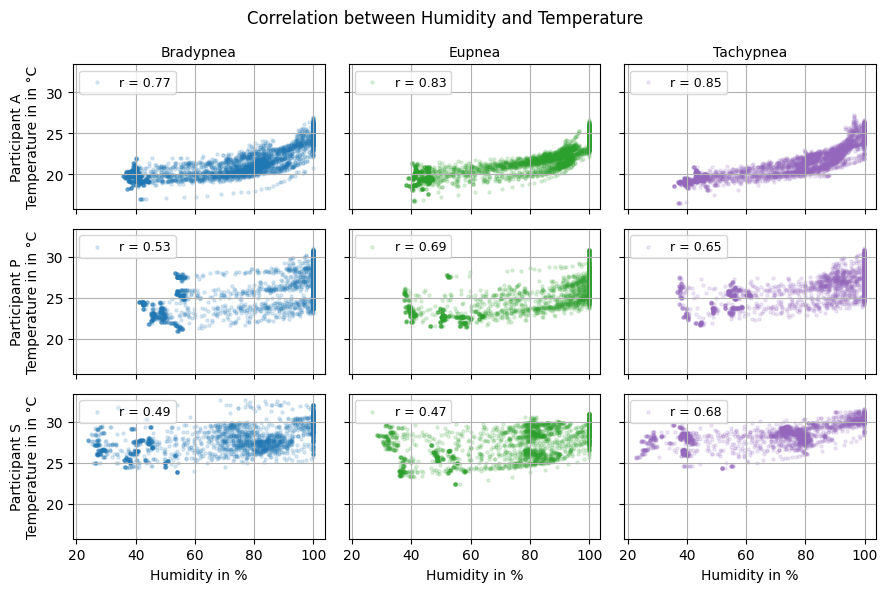

In [7]:
plot_correlation(breath_pattern)

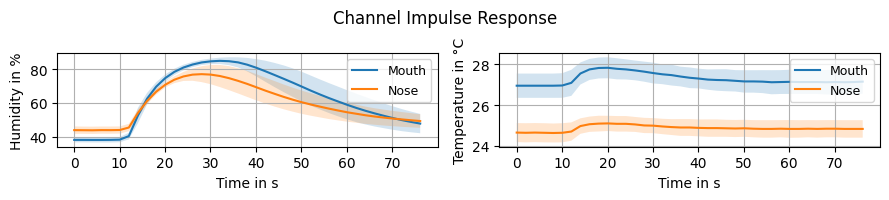

In [8]:
cir = load_cir(dataset_dir="./dataset")
plot_cir(cir)

### Train-Real-Test-Real

In [1]:
from core.plotting import load_trtr_features, plot_trtr_ablation, plot_trtr_feature_count, plot_trtr_feature_stability, plot_trtr_channel_contribution

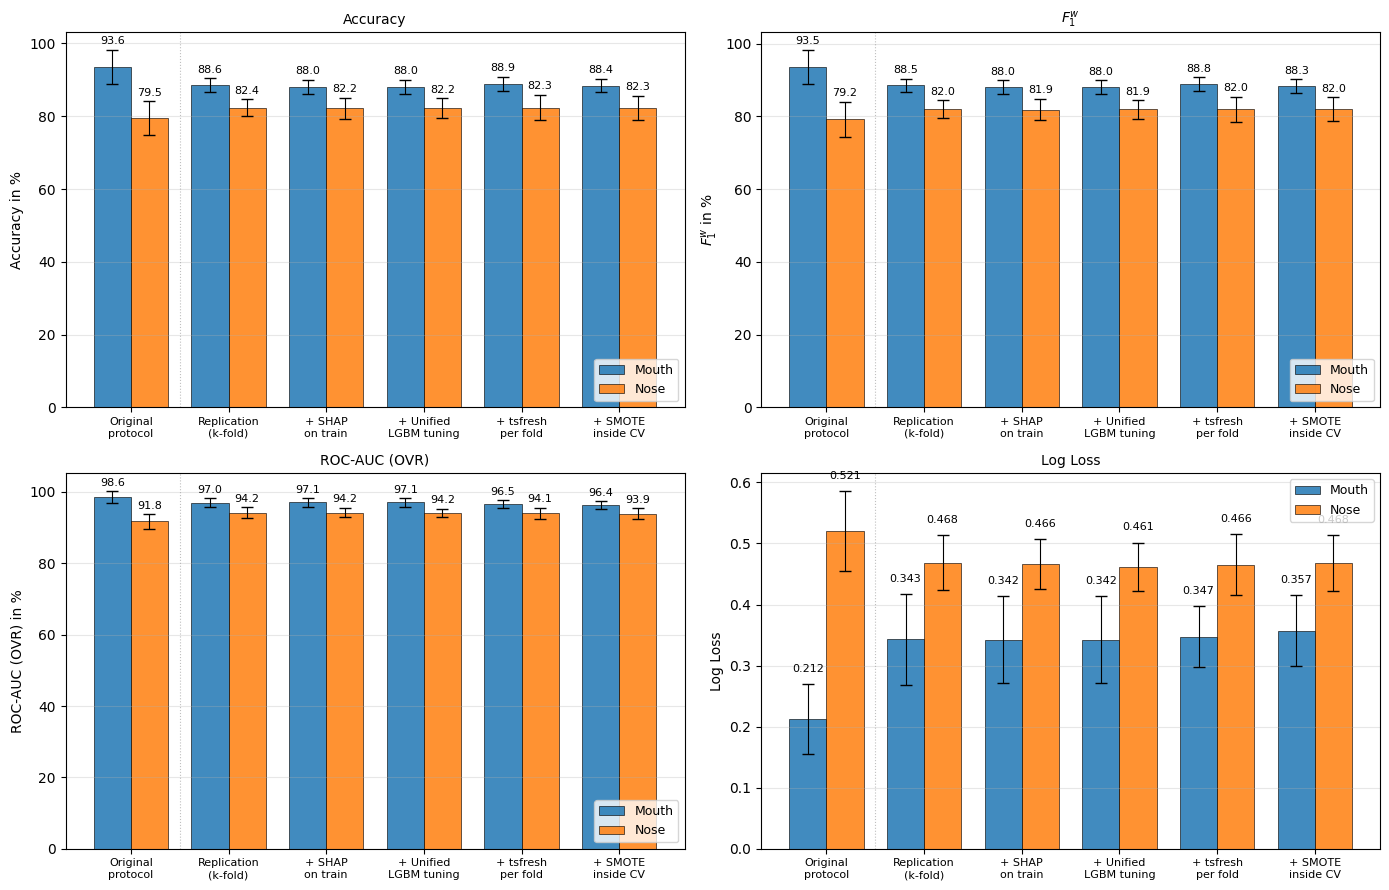

In [2]:
plot_trtr_ablation()

In [3]:
feature_counts = load_trtr_features()

FileNotFoundError: [Errno 2] No such file or directory: './results/trtr/mouth_s0_tstr.json'

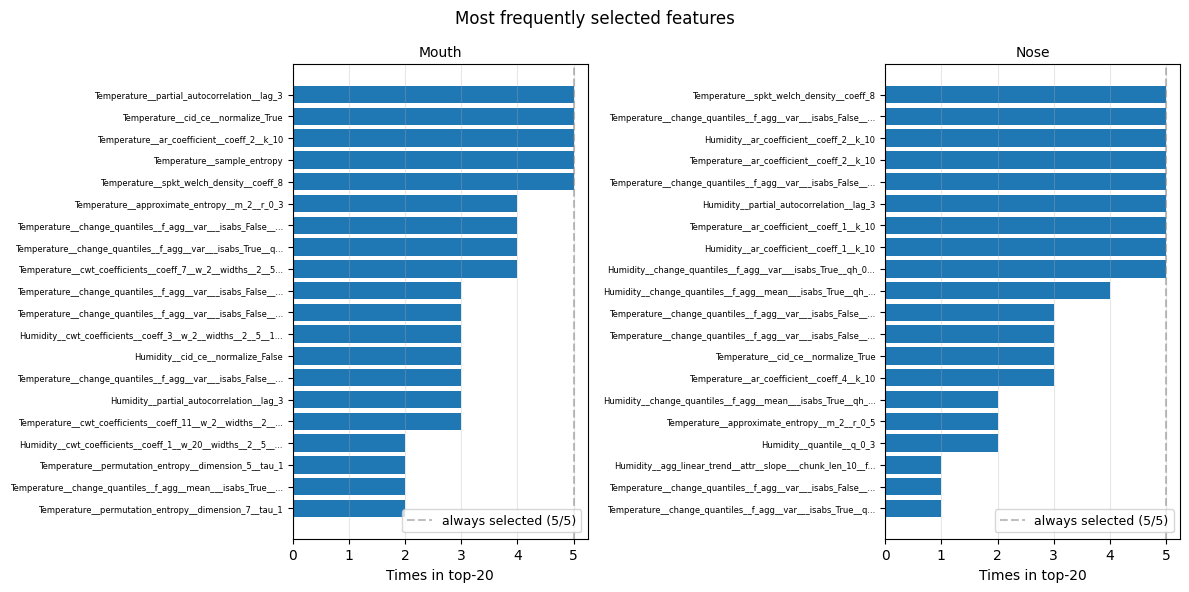

In [4]:
plot_trtr_feature_count(feature_counts)

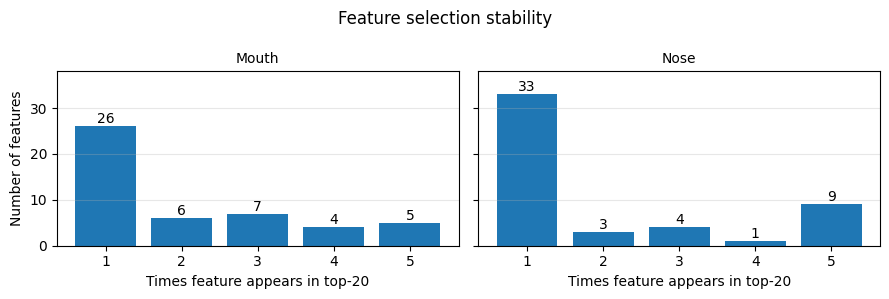

In [5]:
plot_trtr_feature_stability(feature_counts)

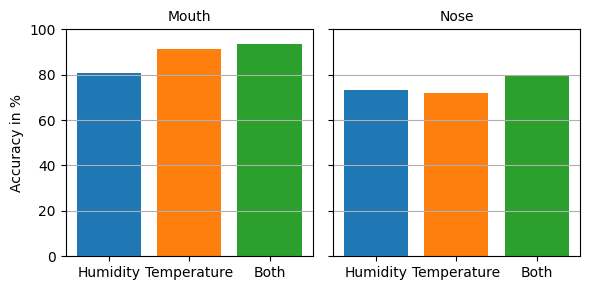

In [2]:
plot_trtr_channel_contribution()

### Variational Autoencoder

In [14]:
from core.plotting import load_vaes, plot_vae_training, plot_vae_active_dims_training, plot_vae_active_dims_final, plot_vae_tSNE

In [15]:
models, datasets = load_vaes(device)

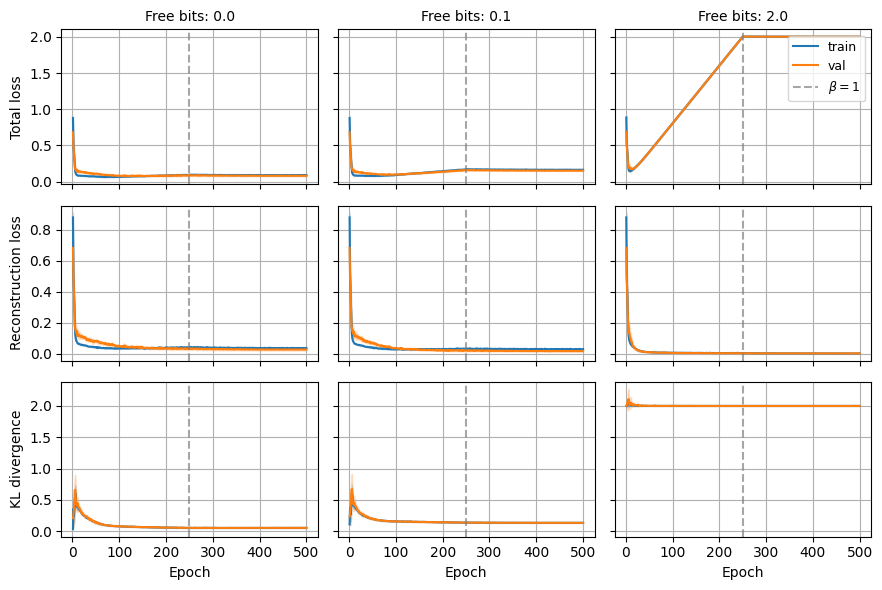

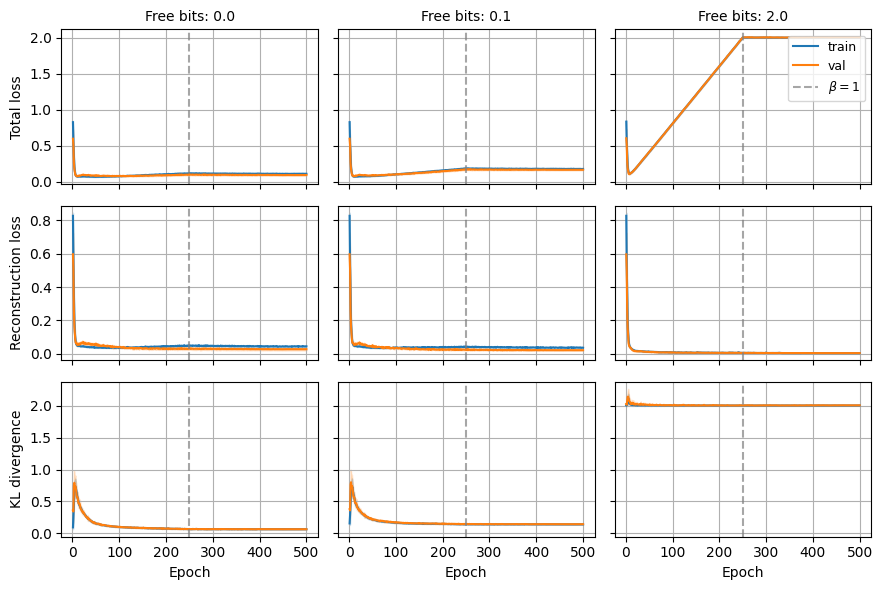

In [ ]:
plot_vae_training("mouth")
plot_vae_training("nose")

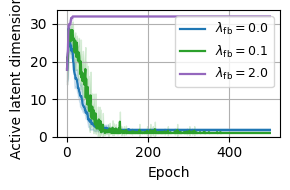

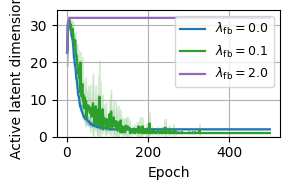

In [ ]:
plot_vae_active_dims_training("mouth")
plot_vae_active_dims_training("nose")

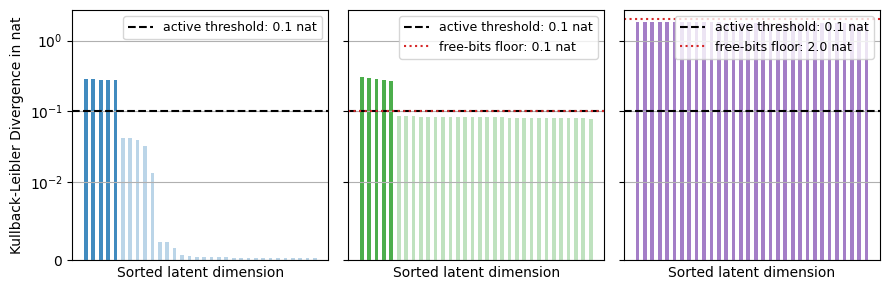

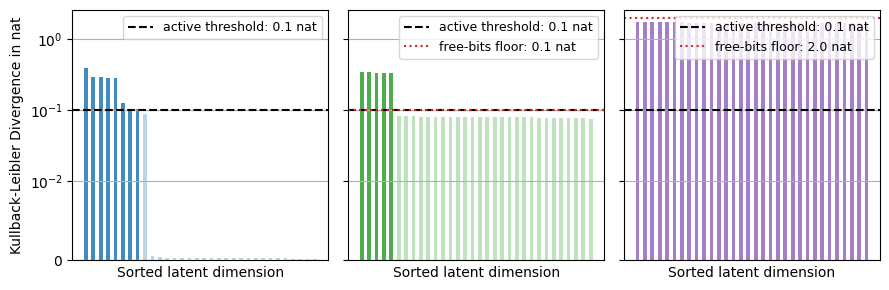

In [18]:
plot_vae_active_dims_final(models, datasets, region="mouth")
plot_vae_active_dims_final(models, datasets, region="nose")

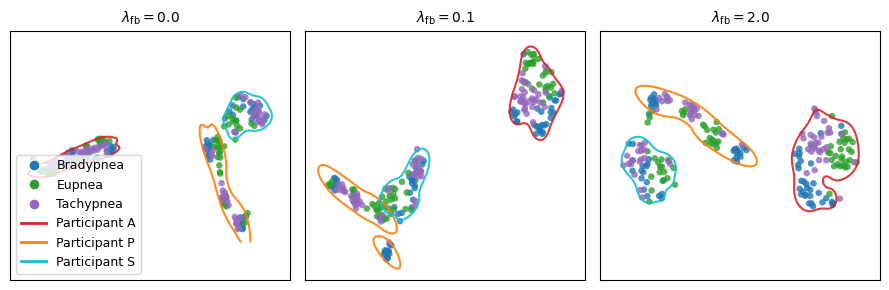

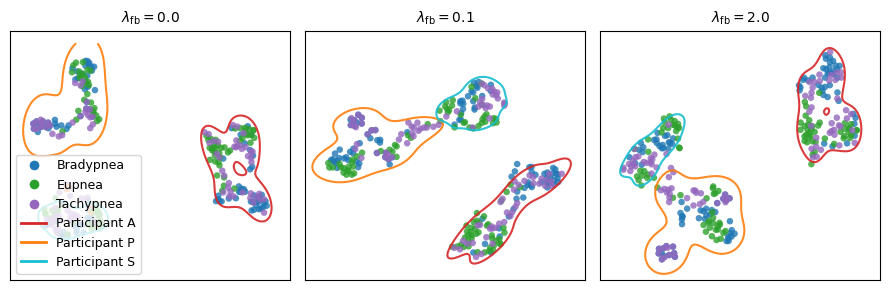

In [19]:
plot_vae_tSNE(models, datasets, region="mouth")
plot_vae_tSNE(models, datasets, region="nose")

### Conditional Variational Autoencoder

In [20]:
from core.plotting import load_cvae_ablation_data, load_cvaes, plot_cvae_architecture_ablation, plot_cvae_architecture_dynamics, plot_cvae_beta_sweep, plot_cvae_beta_active_dims, plot_cvae_tSNE, plot_cvae_lag, plot_cvae_summary, plot_cvae_jittering

In [21]:
arch_summary, arch_history, dyn_summary, dyn_history = load_cvae_ablation_data()

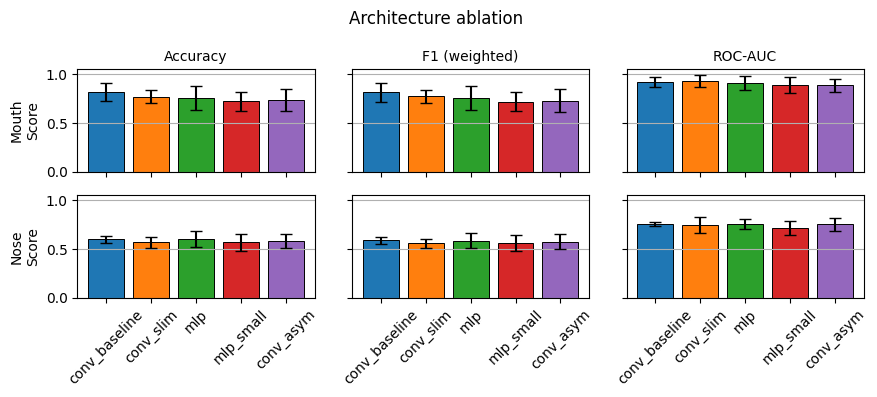

In [22]:
plot_cvae_architecture_ablation(arch_summary)

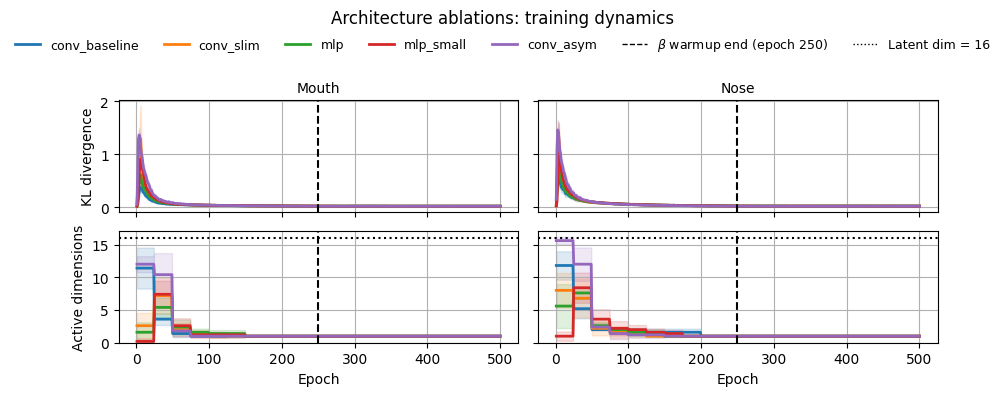

In [23]:
plot_cvae_architecture_dynamics(arch_history)

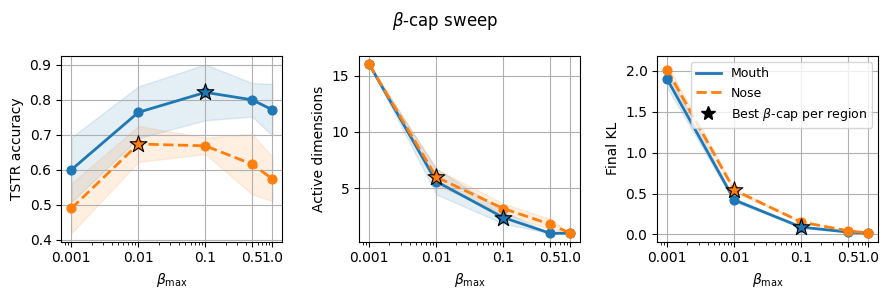

In [24]:
plot_cvae_beta_sweep(dyn_summary)

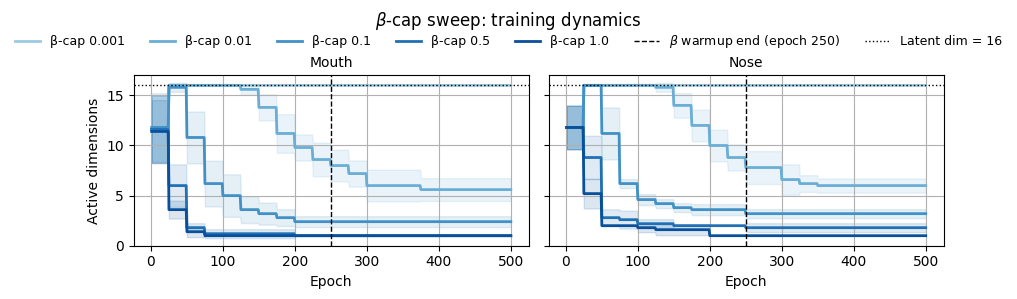

In [25]:
plot_cvae_beta_active_dims(dyn_history)

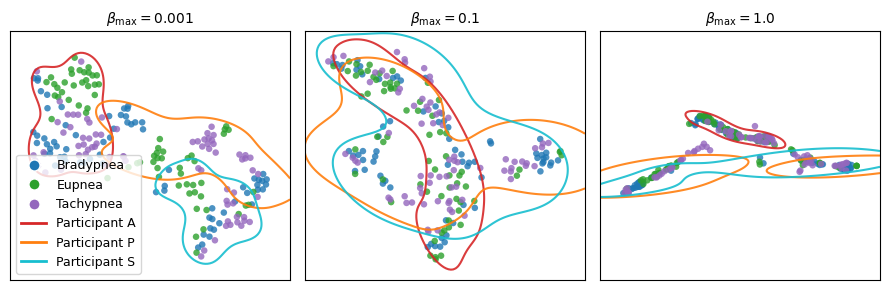

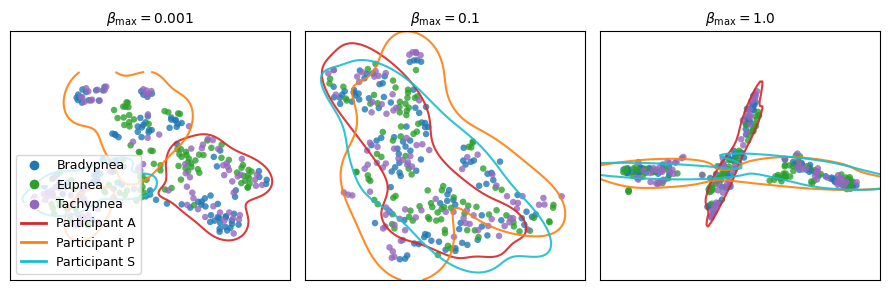

In [26]:
models, datasets = load_cvaes(device)
plot_cvae_tSNE(models, datasets, region="mouth")
plot_cvae_tSNE(models, datasets, region="nose")

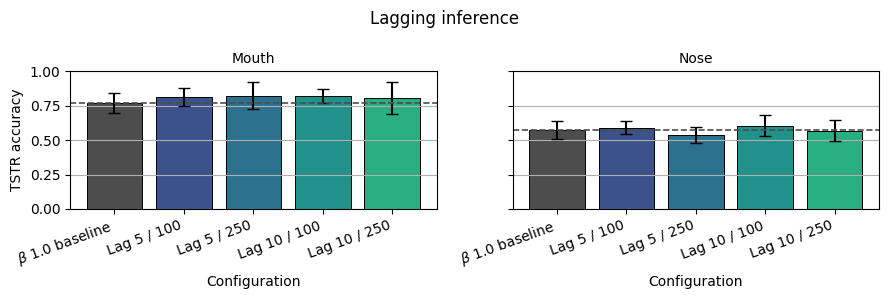

In [27]:
plot_cvae_lag(dyn_summary)

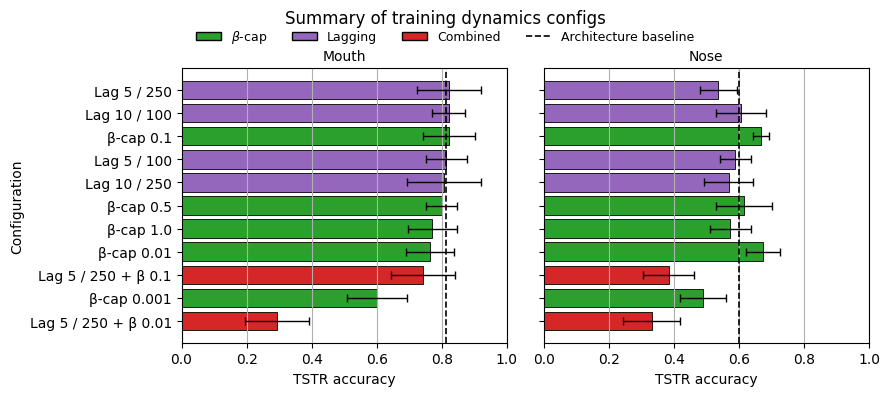

In [28]:
plot_cvae_summary(dyn_summary, arch_summary)

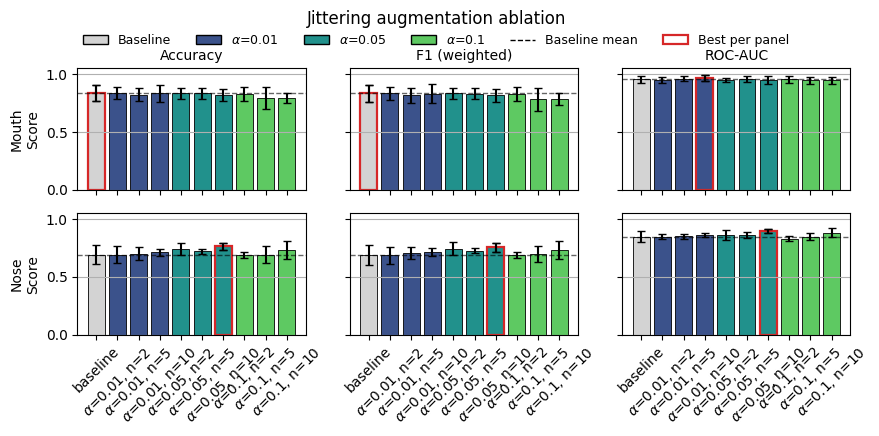

In [29]:
plot_cvae_jittering()

### Physics-Informed Conditional Variational Autoencoder